<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/14simple_imputor_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

Load the dataset using Pandas.

Check missing values using isnull().sum().

Replace invalid 0 values in columns like Glucose, BloodPressure, and BMI with NaN.

Apply:

Necessary Imputation ( Must be done with the proper one )
Create a categorical column:

Age_Group

Young (<30)

Adult (30–50)

Senior (>50)

Apply Encoding on Age_Group. Choose the proper encoding technique and explain why it is the best one.

In [2]:
df = pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
# df.loc[df['Glucose'] == 0, 'Glucose'] = np.nan
cols_to_replace = ['Glucose', 'BloodPressure', 'BMI']
df[cols_to_replace] = df[cols_to_replace].replace(0, np.nan)

In [5]:
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
69,4,146.0,85.0,27,100,28.9,0.189,27,0
61,8,133.0,72.0,0,0,32.9,0.270,39,1
162,0,114.0,80.0,34,285,44.2,0.167,27,0
185,7,194.0,68.0,28,0,35.9,0.745,41,1
723,5,117.0,86.0,30,105,39.1,0.251,42,0
385,1,119.0,54.0,13,50,22.3,0.205,24,0
189,5,139.0,80.0,35,160,31.6,0.361,25,1
142,2,108.0,52.0,26,63,32.5,0.318,22,0
182,1,NaN,74.0,20,23,27.7,0.299,21,0
50,1,103.0,80.0,11,82,19.4,0.491,22,0


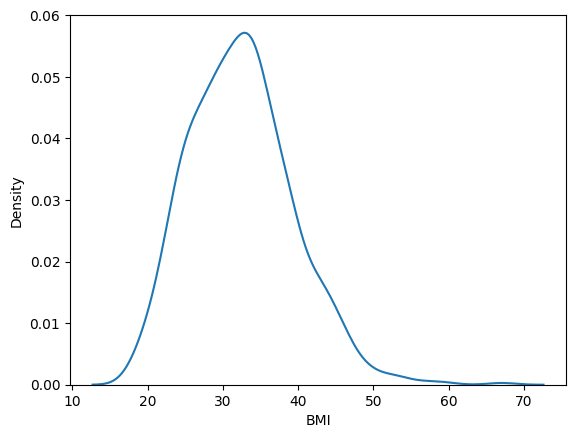

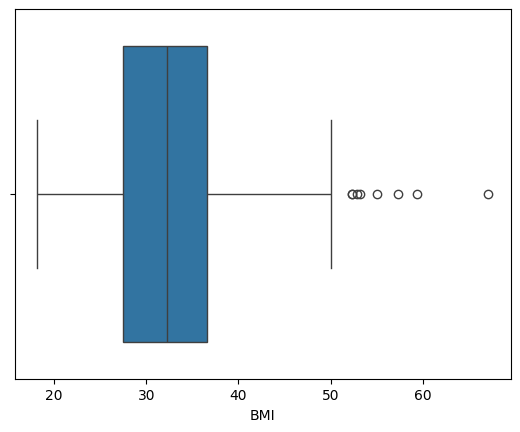

In [6]:
sns.kdeplot(data = df, x = 'BMI')
plt.show()
sns.boxplot(data = df, x = 'BMI')
plt.show()

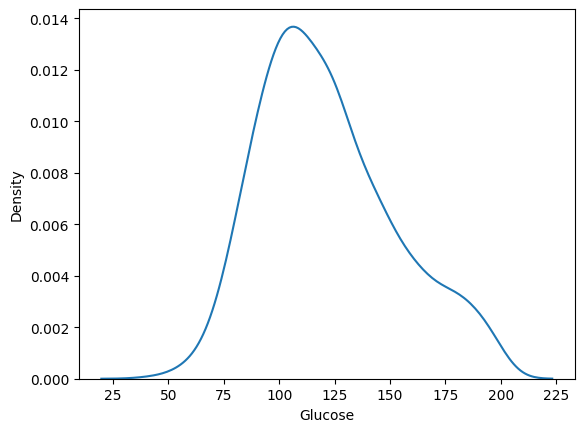

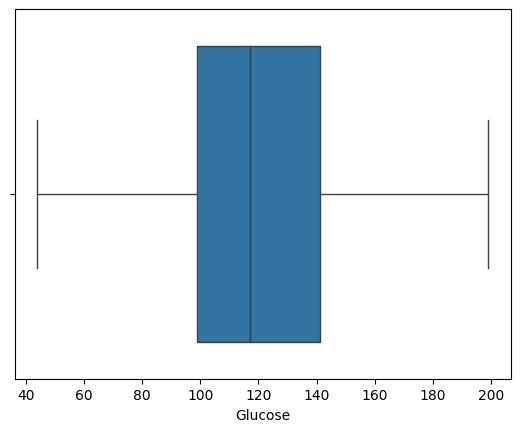

In [7]:
sns.kdeplot(data = df, x = 'Glucose')
plt.show()
sns.boxplot(data = df, x = 'Glucose')
plt.show()

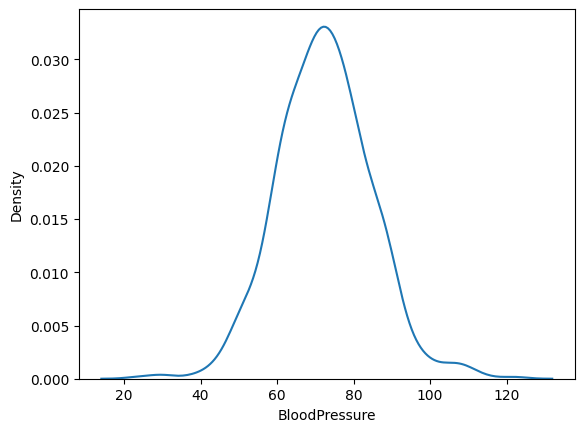

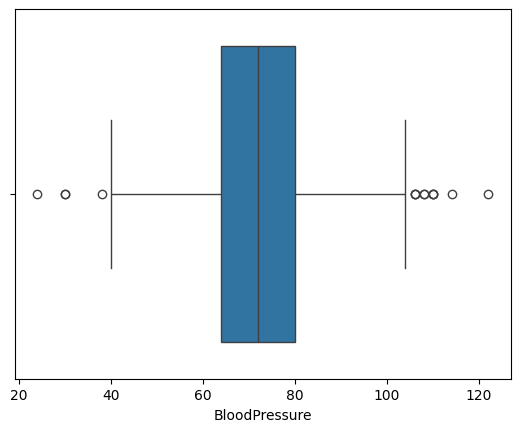

In [8]:
sns.kdeplot(data = df, x = 'BloodPressure')
plt.show()
sns.boxplot(data = df, x = 'BloodPressure')
plt.show()

The data are skewed. so median replacement needed

In [9]:
for col in cols_to_replace:
  median_value = df[col].median()
  df[col] = df[col].fillna(median_value)

In [10]:
BMI_imputor = SimpleImputer(missing_values=np.nan, strategy='median')
BMI_imputor.fit(df[['BMI']])
df['BMI'] = BMI_imputor.transform(df[['BMI']]).ravel()

In [11]:
df.loc[(df['Age']) < 30 , 'Age_group'] = 'Young'
df.loc[(df['Age'] >=30) & (df['Age'] <= 50) , 'Age_group'] = 'Adult'
df.loc[(df['Age']) > 50 , 'Age_group'] = 'Senior'

In [12]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_group
0,6,148.0,72.0,35,0,33.6,0.627,50,1,Adult
1,1,85.0,66.0,29,0,26.6,0.351,31,0,Adult
2,8,183.0,64.0,0,0,23.3,0.672,32,1,Adult
3,1,89.0,66.0,23,94,28.1,0.167,21,0,Young
4,0,137.0,40.0,35,168,43.1,2.288,33,1,Adult
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48,180,32.9,0.171,63,0,Senior
764,2,122.0,70.0,27,0,36.8,0.340,27,0,Young
765,5,121.0,72.0,23,112,26.2,0.245,30,0,Adult
766,1,126.0,60.0,0,0,30.1,0.349,47,1,Adult


In [13]:
from sklearn.preprocessing import OrdinalEncoder

In [14]:
age_encoder = OrdinalEncoder(categories = [['Young', 'Adult', 'Senior']])
age_encoder.fit(df[['Age_group']])
df['Encoded_age_group'] = age_encoder.transform(df[['Age_group']]).ravel()

Age_group is a ordinal variable. That's why oridnal category is best

In [15]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_group,Encoded_age_group
0,6,148.0,72.0,35,0,33.6,0.627,50,1,Adult,1.0
1,1,85.0,66.0,29,0,26.6,0.351,31,0,Adult,1.0
2,8,183.0,64.0,0,0,23.3,0.672,32,1,Adult,1.0
3,1,89.0,66.0,23,94,28.1,0.167,21,0,Young,0.0
4,0,137.0,40.0,35,168,43.1,2.288,33,1,Adult,1.0
...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48,180,32.9,0.171,63,0,Senior,2.0
764,2,122.0,70.0,27,0,36.8,0.340,27,0,Young,0.0
765,5,121.0,72.0,23,112,26.2,0.245,30,0,Adult,1.0
766,1,126.0,60.0,0,0,30.1,0.349,47,1,Adult,1.0


Use the Heart Disease UCI Dataset dataset.

Tasks:

Load the dataset.

Identify categorical columns.

Apply  Encoding on:

cp (chest pain type)

thal

Compare dataframe shape before and after encoding.


In [16]:
df = pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [17]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [18]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

[]


In [19]:
before_data_shape = df.shape

In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
cp_one_hot_encoding = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
cp_one_hot_encoding.fit(df[['cp']])
encoded_cp = cp_one_hot_encoding.transform(df[['cp']])
df = pd.concat([df, encoded_cp], axis = 1)

In [22]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_0,cp_1,cp_2,cp_3
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,1.0,0.0,0.0,0.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,1.0,0.0,0.0,0.0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,1.0,0.0,0.0,0.0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,1.0,0.0,0.0,0.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1,0.0,1.0,0.0,0.0
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0,1.0,0.0,0.0,0.0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0,1.0,0.0,0.0,0.0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1,1.0,0.0,0.0,0.0


In [23]:
before_data_shape, df.shape

((1025, 14), (1025, 18))

Use the Tips Dataset dataset.

Tasks:

Load dataset using Seaborn.

Apply  Encoding on:

sex

smoker

Create a new feature:

tip_category

Low (<3)

Medium (3–6)

High (>6)

Encode tip_category.

Choose the proper encoding technique and explain why it is the best one.


In [24]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [25]:
sex_one_hot_encoding = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
sex_one_hot_encoding.fit(df[['sex']])
encoded_sex = sex_one_hot_encoding.transform(df[['sex']])
df = pd.concat([df, encoded_sex], axis = 1)

In [26]:
df

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0


Use the Car Price Prediction Dataset dataset.

Tasks:

Split the dataset into train and test sets first.

Apply:

Ordinal Encoding on fuel type (Petrol, Diesel, CNG)

One Hot Encoding on transmission type

Handle unknown categories in test data properly.

Concatenate encoded columns with original dataframe.

Drop original categorical columns.


In [27]:
df = pd.read_csv('/content/CarPrice_Assignment.csv')
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [28]:
print(df)

     car_ID  symboling                   CarName fueltype aspiration  \
0         1          3        alfa-romero giulia      gas        std   
1         2          3       alfa-romero stelvio      gas        std   
2         3          1  alfa-romero Quadrifoglio      gas        std   
3         4          2               audi 100 ls      gas        std   
4         5          2                audi 100ls      gas        std   
..      ...        ...                       ...      ...        ...   
200     201         -1           volvo 145e (sw)      gas        std   
201     202         -1               volvo 144ea      gas      turbo   
202     203         -1               volvo 244dl      gas        std   
203     204         -1                 volvo 246   diesel      turbo   
204     205         -1               volvo 264gl      gas      turbo   

    doornumber      carbody drivewheel enginelocation  wheelbase  ...  \
0          two  convertible        rwd          front       88

In [29]:
total_fuel_type = df['fueltype'].nunique()
print(total_fuel_type)
print(df['fueltype'].unique())

2
['gas' 'diesel']


In [30]:
X = df.drop(['price'], axis = 1)
y = df['price']

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
display(X_train)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
66,67,0,mazda rx-7 gs,diesel,std,four,sedan,rwd,front,104.9,...,four,134,idi,3.43,3.64,22.0,72,4200,31,39
111,112,0,peugeot 504,gas,std,four,sedan,rwd,front,107.9,...,four,120,mpfi,3.46,2.19,8.4,95,5000,19,24
153,154,0,toyota corona hardtop,gas,std,four,wagon,fwd,front,95.7,...,four,92,2bbl,3.05,3.03,9.0,62,4800,31,37
96,97,1,nissan latio,gas,std,four,sedan,fwd,front,94.5,...,four,97,2bbl,3.15,3.29,9.4,69,5200,31,37
38,39,0,honda civic 1300,gas,std,two,hatchback,fwd,front,96.5,...,four,110,1bbl,3.15,3.58,9.0,86,5800,27,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,nissan clipper,gas,std,two,hatchback,rwd,front,99.2,...,six,181,mpfi,3.43,3.27,9.0,160,5200,19,25
14,15,1,bmw z4,gas,std,four,sedan,rwd,front,103.5,...,six,164,mpfi,3.31,3.19,9.0,121,4250,20,25
92,93,1,nissan latio,gas,std,four,sedan,fwd,front,94.5,...,four,97,2bbl,3.15,3.29,9.4,69,5200,31,37
179,180,3,toyota corona,gas,std,two,hatchback,rwd,front,102.9,...,six,171,mpfi,3.27,3.35,9.3,161,5200,19,24


In [33]:
display(y_train)

,price
66,18344.0
111,15580.0
153,6918.0
96,7499.0
38,9095.0
...,...
106,18399.0
14,24565.0
92,6849.0
179,15998.0


In [34]:
fuel_encoder = OrdinalEncoder(categories = [['gas', 'diesel']])
fuel_encoder.fit(X_train[['fueltype']])
X_train['Encoded_fueltype'] = fuel_encoder.transform(X_train[['fueltype']]).ravel()

In [35]:
X_train

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,Encoded_fueltype
66,67,0,mazda rx-7 gs,diesel,std,four,sedan,rwd,front,104.9,...,134,idi,3.43,3.64,22.0,72,4200,31,39,1.0
111,112,0,peugeot 504,gas,std,four,sedan,rwd,front,107.9,...,120,mpfi,3.46,2.19,8.4,95,5000,19,24,0.0
153,154,0,toyota corona hardtop,gas,std,four,wagon,fwd,front,95.7,...,92,2bbl,3.05,3.03,9.0,62,4800,31,37,0.0
96,97,1,nissan latio,gas,std,four,sedan,fwd,front,94.5,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,0.0
38,39,0,honda civic 1300,gas,std,two,hatchback,fwd,front,96.5,...,110,1bbl,3.15,3.58,9.0,86,5800,27,33,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,nissan clipper,gas,std,two,hatchback,rwd,front,99.2,...,181,mpfi,3.43,3.27,9.0,160,5200,19,25,0.0
14,15,1,bmw z4,gas,std,four,sedan,rwd,front,103.5,...,164,mpfi,3.31,3.19,9.0,121,4250,20,25,0.0
92,93,1,nissan latio,gas,std,four,sedan,fwd,front,94.5,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,0.0
179,180,3,toyota corona,gas,std,two,hatchback,rwd,front,102.9,...,171,mpfi,3.27,3.35,9.3,161,5200,19,24,0.0


In [36]:
X_test['Encoded_fueltype'] = fuel_encoder.transform(X_test[['fueltype']]).ravel()

In [37]:
X_test

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,Encoded_fueltype
15,16,0,bmw x4,gas,std,four,sedan,rwd,front,103.5,...,209,mpfi,3.62,3.390,8.00,182,5400,16,22,0.0
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.400,7.00,160,5500,16,22,0.0
100,101,0,nissan nv200,gas,std,four,sedan,fwd,front,97.2,...,120,2bbl,3.33,3.470,8.50,97,5200,27,34,0.0
132,133,3,saab 99e,gas,std,two,hatchback,fwd,front,99.1,...,121,mpfi,3.54,3.070,9.31,110,5250,21,28,0.0
68,69,-1,buick century luxus (sw),diesel,turbo,four,wagon,rwd,front,110.0,...,183,idi,3.58,3.640,21.50,123,4350,22,25,1.0
95,96,1,nissan juke,gas,std,two,hatchback,fwd,front,94.5,...,97,2bbl,3.15,3.290,9.40,69,5200,31,37,0.0
159,160,0,toyota corolla,diesel,std,four,hatchback,fwd,front,95.7,...,110,idi,3.27,3.350,22.50,56,4500,38,47,1.0
162,163,0,toyota mark ii,gas,std,four,sedan,fwd,front,95.7,...,98,2bbl,3.19,3.030,9.00,70,4800,28,34,0.0
147,148,0,subaru tribeca,gas,std,four,wagon,fwd,front,97.0,...,108,mpfi,3.62,2.640,9.00,94,5200,25,31,0.0
182,183,2,vokswagen rabbit,diesel,std,two,sedan,fwd,front,97.3,...,97,idi,3.01,3.400,23.00,52,4800,37,46,1.0


In [38]:
X_train.drop(['fueltype'], axis = 1, inplace = True)
X_train

,car_ID,symboling,CarName,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,Encoded_fueltype
66,67,0,mazda rx-7 gs,std,four,sedan,rwd,front,104.9,175.0,...,134,idi,3.43,3.64,22.0,72,4200,31,39,1.0
111,112,0,peugeot 504,std,four,sedan,rwd,front,107.9,186.7,...,120,mpfi,3.46,2.19,8.4,95,5000,19,24,0.0
153,154,0,toyota corona hardtop,std,four,wagon,fwd,front,95.7,169.7,...,92,2bbl,3.05,3.03,9.0,62,4800,31,37,0.0
96,97,1,nissan latio,std,four,sedan,fwd,front,94.5,165.3,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,0.0
38,39,0,honda civic 1300,std,two,hatchback,fwd,front,96.5,167.5,...,110,1bbl,3.15,3.58,9.0,86,5800,27,33,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,nissan clipper,std,two,hatchback,rwd,front,99.2,178.5,...,181,mpfi,3.43,3.27,9.0,160,5200,19,25,0.0
14,15,1,bmw z4,std,four,sedan,rwd,front,103.5,189.0,...,164,mpfi,3.31,3.19,9.0,121,4250,20,25,0.0
92,93,1,nissan latio,std,four,sedan,fwd,front,94.5,165.3,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,0.0
179,180,3,toyota corona,std,two,hatchback,rwd,front,102.9,183.5,...,171,mpfi,3.27,3.35,9.3,161,5200,19,24,0.0


In [39]:
X_test.drop(['fueltype'], axis = 1, inplace = True)
X_test

,car_ID,symboling,CarName,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,Encoded_fueltype
15,16,0,bmw x4,std,four,sedan,rwd,front,103.5,189.0,...,209,mpfi,3.62,3.390,8.00,182,5400,16,22,0.0
9,10,0,audi 5000s (diesel),turbo,two,hatchback,4wd,front,99.5,178.2,...,131,mpfi,3.13,3.400,7.00,160,5500,16,22,0.0
100,101,0,nissan nv200,std,four,sedan,fwd,front,97.2,173.4,...,120,2bbl,3.33,3.470,8.50,97,5200,27,34,0.0
132,133,3,saab 99e,std,two,hatchback,fwd,front,99.1,186.6,...,121,mpfi,3.54,3.070,9.31,110,5250,21,28,0.0
68,69,-1,buick century luxus (sw),turbo,four,wagon,rwd,front,110.0,190.9,...,183,idi,3.58,3.640,21.50,123,4350,22,25,1.0
95,96,1,nissan juke,std,two,hatchback,fwd,front,94.5,165.6,...,97,2bbl,3.15,3.290,9.40,69,5200,31,37,0.0
159,160,0,toyota corolla,std,four,hatchback,fwd,front,95.7,166.3,...,110,idi,3.27,3.350,22.50,56,4500,38,47,1.0
162,163,0,toyota mark ii,std,four,sedan,fwd,front,95.7,166.3,...,98,2bbl,3.19,3.030,9.00,70,4800,28,34,0.0
147,148,0,subaru tribeca,std,four,wagon,fwd,front,97.0,173.5,...,108,mpfi,3.62,2.640,9.00,94,5200,25,31,0.0
182,183,2,vokswagen rabbit,std,two,sedan,fwd,front,97.3,171.7,...,97,idi,3.01,3.400,23.00,52,4800,37,46,1.0


Build a preprocessing pipeline that includes:

Missing value imputation

Outlier detection using IQR

One Hot Encoding

Ordinal Encoding

Use ColumnTransformer and Pipeline.

Transform both training and testing datasets properly.

Display final transformed feature matrix shape

In [40]:
df = pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [41]:
X = df.drop(['target'], axis = 1)
y = df['target']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [44]:
X_test.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Split the dataset into train and test sets.

Detects all categorical columns automatically.

Apply:

Ordinal Encoding for education level

One Hot Encoding for department

Label Encoding for target column

Handle unseen categories in test data.

Create a reusable preprocessing function.

Display transformed train and test datasets.

In [45]:
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [46]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [47]:
print(df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [48]:
X = df.drop(['Attrition'], axis = 1)
y = df['Attrition']

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
total_fuel_type = df['EducationField'].nunique()
print(total_fuel_type)
print(df['EducationField'].unique())

6
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']


In [51]:
education_encoder = OrdinalEncoder(categories = [['Life Sciences', 'Other', 'Medical','Marketing' ,'Technical Degree',
 'Human Resources']])
education_encoder.fit(X_train[['EducationField']])
X_train['Encoded_education'] = education_encoder.transform(X_train[['EducationField']]).ravel()

In [52]:
X_train

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Encoded_education
1097,24,Travel_Rarely,350,Research & Development,21,2,Technical Degree,1,1551,3,...,80,3,2,3,3,1,1,0,0,4.0
727,18,Non-Travel,287,Research & Development,5,2,Life Sciences,1,1012,2,...,80,0,0,2,3,0,0,0,0,0.0
254,29,Travel_Rarely,1247,Sales,20,2,Marketing,1,349,4,...,80,1,10,2,3,3,2,0,2,3.0
1175,39,Travel_Rarely,492,Research & Development,12,3,Medical,1,1654,4,...,80,0,7,3,3,5,4,1,0,2.0
1341,31,Travel_Rarely,311,Research & Development,20,3,Life Sciences,1,1881,2,...,80,1,10,2,3,10,8,0,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,35,Travel_Rarely,750,Research & Development,28,3,Life Sciences,1,1596,2,...,80,2,10,3,2,10,9,6,8,0.0
1294,41,Travel_Rarely,447,Research & Development,5,3,Life Sciences,1,1814,2,...,80,0,11,3,1,3,2,1,2,0.0
860,22,Travel_Frequently,1256,Research & Development,3,4,Life Sciences,1,1203,3,...,80,1,1,5,3,0,0,0,0,0.0
1459,29,Travel_Rarely,1378,Research & Development,13,2,Other,1,2053,4,...,80,1,10,2,3,4,3,0,3,1.0


In [53]:
X_test['Encoded_education'] = education_encoder.transform(X_test[['EducationField']]).ravel()

In [54]:
X_test

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Encoded_education
1041,28,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,...,80,0,6,4,3,5,4,1,3,2.0
184,53,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,...,80,2,5,3,3,4,2,1,3,2.0
1222,24,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,...,80,1,1,2,3,1,0,0,0,5.0
67,45,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,...,80,1,25,2,3,1,0,0,0,0.0
220,36,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,...,80,0,16,3,4,13,11,3,7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,34,Travel_Rarely,304,Sales,2,3,Other,1,786,4,...,80,0,6,5,3,6,5,1,4,1.0
560,34,Travel_Rarely,167,Research & Development,8,5,Life Sciences,1,775,2,...,80,1,7,3,3,0,0,0,0,0.0
945,50,Travel_Rarely,1322,Research & Development,28,3,Life Sciences,1,1317,4,...,80,0,25,2,3,3,2,1,2,0.0
522,37,Travel_Rarely,1225,Research & Development,10,2,Life Sciences,1,715,4,...,80,0,4,2,3,1,0,0,0,0.0


In [55]:
department_one_hot_encoding = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
department_one_hot_encoding.fit(X_train[['Department']])
encoded_department = department_one_hot_encoding.transform(X_train[['Department']])
X_train = pd.concat([X_train, encoded_department], axis = 1)

In [56]:
X_train

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Encoded_education,Department_Human Resources,Department_Research & Development,Department_Sales
1097,24,Travel_Rarely,350,Research & Development,21,2,Technical Degree,1,1551,3,...,3,3,1,1,0,0,4.0,0.0,1.0,0.0
727,18,Non-Travel,287,Research & Development,5,2,Life Sciences,1,1012,2,...,2,3,0,0,0,0,0.0,0.0,1.0,0.0
254,29,Travel_Rarely,1247,Sales,20,2,Marketing,1,349,4,...,2,3,3,2,0,2,3.0,0.0,0.0,1.0
1175,39,Travel_Rarely,492,Research & Development,12,3,Medical,1,1654,4,...,3,3,5,4,1,0,2.0,0.0,1.0,0.0
1341,31,Travel_Rarely,311,Research & Development,20,3,Life Sciences,1,1881,2,...,2,3,10,8,0,2,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,35,Travel_Rarely,750,Research & Development,28,3,Life Sciences,1,1596,2,...,3,2,10,9,6,8,0.0,0.0,1.0,0.0
1294,41,Travel_Rarely,447,Research & Development,5,3,Life Sciences,1,1814,2,...,3,1,3,2,1,2,0.0,0.0,1.0,0.0
860,22,Travel_Frequently,1256,Research & Development,3,4,Life Sciences,1,1203,3,...,5,3,0,0,0,0,0.0,0.0,1.0,0.0
1459,29,Travel_Rarely,1378,Research & Development,13,2,Other,1,2053,4,...,2,3,4,3,0,3,1.0,0.0,1.0,0.0


In [57]:
encoded_department = department_one_hot_encoding.transform(X_test[['Department']])
X_test = pd.concat([X_test, encoded_department], axis = 1)

In [58]:
X_test

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Encoded_education,Department_Human Resources,Department_Research & Development,Department_Sales
1041,28,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,...,4,3,5,4,1,3,2.0,0.0,0.0,1.0
184,53,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,...,3,3,4,2,1,3,2.0,0.0,1.0,0.0
1222,24,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,...,2,3,1,0,0,0,5.0,1.0,0.0,0.0
67,45,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,...,2,3,1,0,0,0,0.0,0.0,1.0,0.0
220,36,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,...,3,4,13,11,3,7,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,34,Travel_Rarely,304,Sales,2,3,Other,1,786,4,...,5,3,6,5,1,4,1.0,0.0,0.0,1.0
560,34,Travel_Rarely,167,Research & Development,8,5,Life Sciences,1,775,2,...,3,3,0,0,0,0,0.0,0.0,1.0,0.0
945,50,Travel_Rarely,1322,Research & Development,28,3,Life Sciences,1,1317,4,...,2,3,3,2,1,2,0.0,0.0,1.0,0.0
522,37,Travel_Rarely,1225,Research & Development,10,2,Life Sciences,1,715,4,...,2,3,1,0,0,0,0.0,0.0,1.0,0.0


In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)

y_train_array = le.transform(y_train)
y_test_array = le.transform(y_test)

In [60]:
y_train = pd.Series(y_train_array, index = y_train.index, name = y_train.name)
y_test = pd.Series(y_test_array, index = y_test.index, name = y_test.name)

In [61]:
y_train

,Attrition
1097,0
727,0
254,0
1175,0
1341,0
...,...
1130,0
1294,0
860,1
1459,0


In [62]:
y_test

,Attrition
1041,0
184,0
1222,1
67,0
220,0
...,...
567,0
560,0
945,0
522,0


In [63]:
def preprocess_hr_dataset(df, target_col = 'Attrition', test_size = 0.2):
  X = df.drop([target_col], axis = 1)
  y = df[target_col]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state=42)

  return X_train, X_test, y_train, y_test

In [64]:
X_train, X_test, y_train, y_test = preprocess_hr_dataset(df)

In [65]:
X_train

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1097,24,Travel_Rarely,350,Research & Development,21,2,Technical Degree,1,1551,3,...,2,80,3,2,3,3,1,1,0,0
727,18,Non-Travel,287,Research & Development,5,2,Life Sciences,1,1012,2,...,4,80,0,0,2,3,0,0,0,0
254,29,Travel_Rarely,1247,Sales,20,2,Marketing,1,349,4,...,4,80,1,10,2,3,3,2,0,2
1175,39,Travel_Rarely,492,Research & Development,12,3,Medical,1,1654,4,...,3,80,0,7,3,3,5,4,1,0
1341,31,Travel_Rarely,311,Research & Development,20,3,Life Sciences,1,1881,2,...,1,80,1,10,2,3,10,8,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,35,Travel_Rarely,750,Research & Development,28,3,Life Sciences,1,1596,2,...,4,80,2,10,3,2,10,9,6,8
1294,41,Travel_Rarely,447,Research & Development,5,3,Life Sciences,1,1814,2,...,1,80,0,11,3,1,3,2,1,2
860,22,Travel_Frequently,1256,Research & Development,3,4,Life Sciences,1,1203,3,...,2,80,1,1,5,3,0,0,0,0
1459,29,Travel_Rarely,1378,Research & Development,13,2,Other,1,2053,4,...,1,80,1,10,2,3,4,3,0,3


In [66]:
X_test

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,...,4,80,0,6,4,3,5,4,1,3
184,53,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,...,3,80,2,5,3,3,4,2,1,3
1222,24,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,...,3,80,1,1,2,3,1,0,0,0
67,45,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,...,3,80,1,25,2,3,1,0,0,0
220,36,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,...,4,80,0,16,3,4,13,11,3,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,34,Travel_Rarely,304,Sales,2,3,Other,1,786,4,...,3,80,0,6,5,3,6,5,1,4
560,34,Travel_Rarely,167,Research & Development,8,5,Life Sciences,1,775,2,...,3,80,1,7,3,3,0,0,0,0
945,50,Travel_Rarely,1322,Research & Development,28,3,Life Sciences,1,1317,4,...,2,80,0,25,2,3,3,2,1,2
522,37,Travel_Rarely,1225,Research & Development,10,2,Life Sciences,1,715,4,...,1,80,0,4,2,3,1,0,0,0


In [67]:
y_test

,Attrition
1041,No
184,No
1222,Yes
67,No
220,No
...,...
567,No
560,No
945,No
522,No


In [68]:
y_train

,Attrition
1097,No
727,No
254,No
1175,No
1341,No
...,...
1130,No
1294,No
860,Yes
1459,No
